First 5 rows:


,userId,movieId,rating
0,1,296,5.0
1,1,306,3.5
2,1,307,5.0
3,1,665,5.0
4,1,899,3.5



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   userId   1048575 non-null  int64  
 1   movieId  1048575 non-null  int64  
 2   rating   1048575 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 24.0 MB
None

Missing values:
userId     0
movieId    0
rating     0
dtype: int64

Columns in dataset:
['userId', 'movieId', 'rating']

Numeric features: ['userId', 'movieId']
Categorical features: []

Decision Tree Results
---------------------
RMSE: 1.0127256863417524
MAE : 0.7926801446612053
R²  : 0.07920565830928838

Random Forest Results
---------------------
RMSE: 0.9846818341062686
MAE : 0.7678686877062024
R²  : 0.12949585589777124

Model Comparison


,Model,RMSE,MAE,R2
0,Decision Tree,1.012726,0.792680,0.079206
1,Random Forest,0.984682,0.767869,0.129496



Top 15 Important Features:


,Feature,Importance
1,movieId,0.67642
0,userId,0.32358


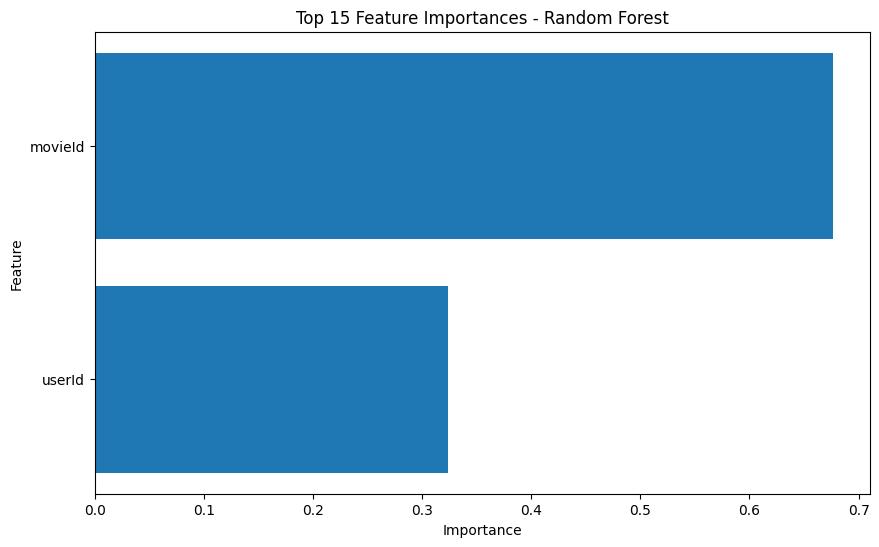

In [1]:
# ============================================
# MovieLens.csv - Decision Tree & Random Forest
# Jupyter Notebook Code
# ============================================

# 1. Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

# 2. Load dataset
df = pd.read_csv("MovieLens.csv")

# 3. Preview data
print("First 5 rows:")
display(df.head())

print("\nDataset info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

# 4. Check columns
print("\nColumns in dataset:")
print(df.columns.tolist())

# 5. Set target column
# Assumes the dataset contains a 'rating' column
target = "rating"

if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found. Available columns: {df.columns.tolist()}")

# 6. Separate features and target
X = df.drop(columns=[target])
y = df[target]

# 7. Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

# 8. Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# 9. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# Decision Tree Regressor
# ============================================
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=10, random_state=42))
])

dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_preds))
dt_mae = mean_absolute_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)

print("\nDecision Tree Results")
print("---------------------")
print("RMSE:", dt_rmse)
print("MAE :", dt_mae)
print("R²  :", dt_r2)

# ============================================
# Random Forest Regressor
# ============================================
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("\nRandom Forest Results")
print("---------------------")
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R²  :", rf_r2)

# ============================================
# Compare Results
# ============================================
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "RMSE": [dt_rmse, rf_rmse],
    "MAE": [dt_mae, rf_mae],
    "R2": [dt_r2, rf_r2]
})

print("\nModel Comparison")
display(results)

# ============================================
# Feature Importance for Random Forest
# ============================================
# Get transformed feature names
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

encoded_cat_features = []
if len(categorical_features) > 0:
    encoded_cat_features = ohe.get_feature_names_out(categorical_features).tolist()

all_feature_names = numeric_features + encoded_cat_features

importances = rf_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features:")
display(feature_importance_df.head(15))

# Plot top 15 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"].head(15)[::-1],
         feature_importance_df["Importance"].head(15)[::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()